## Práctica

Puedes utilizar este notebook para analisar el dataset propuesto

## 1. Definición del problema

El dataset correspondiente a mi grupo de Power BI es el dataset bancario. Como objetivo queremos comprender cómo varía el monto de las transacciónes a lo largo del tiempo y territorio, y poder predecir qué clientes serán morosos.

## 2. Carga del set de datos
Como primer paso importamos las librerías a utilizar, lo cargaremos e iniciaremos el análisis exploratorio para realizar la limpieza del mismo.

In [2]:

# Instalé este paquete para evitar que se superpongan los textos en el gráfico. No encontré una forma de 
# ajustar los textos con matplotlib, así que busqué una librería similar a ggrepel en R. 

!pip install adjustText


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# Cargar el dataset
# Ponemos el separador ";" para que lo lea correctamente
df = pd.read_csv('../data/raw/p4ds-dataset-bancario.csv', sep=';')
df.head()

,Fecha,Número ID,Sucursal,Producto,Monto USD,Vendedor,Estado App,Fecha Registro en la App,estado_mora
0,23/05/2025,1,Durazno,Premier,NaN,NaN,Registrado,24/05/2025,Cobrado
1,14/05/2025,2,Canelones,Préstamo Consumo,"672,0",C2,No Registrado,NaN,Cobrado
2,10/10/2025,3,Montevideo,Tarjeta de Crédito,NaN,NaN,No Registrado,NaN,En Mora
3,15/12/2025,4,Montevideo,Premier,NaN,NaN,Registrado,21/12/2025,Cobrado
4,30/12/2025,5,Montevideo,Préstamo Automotor,"20053,0",M1,Registrado,31/12/2025,Incobrable


## 3. Análisis descriptivo
Como siguiente paso vamos a realizar un análisis descriptivo del dataset. 

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Fecha                     550 non-null    str  
 1   Número ID                 550 non-null    int64
 2   Sucursal                  550 non-null    str  
 3   Producto                  550 non-null    str  
 4   Monto USD                 225 non-null    str  
 5   Vendedor                  225 non-null    str  
 6   Estado App                550 non-null    str  
 7   Fecha Registro en la App  301 non-null    str  
 8   estado_mora               550 non-null    str  
dtypes: int64(1), str(8)
memory usage: 72.4 KB


In [5]:
#Ordenamos las entradas por fecha
df.sort_values("Fecha", inplace=True)

**Variables**: Observamos que hay 9 columnas con datos variables. Todas ellas excepto por "Número ID" están en formato string, mientras que esta única variable es un integer. Las variables disponibles son:
- Fecha: Fecha en formato dd/mm/aaaa de la transacción
- Número ID: Identificador de la transacción
- Sucursal: Departamento de la sucursal correspondiente
- Producto: Servicio de la empresa por el que se realizó la transacción
- Monto USD: Valor de la transacción realizada.
- Vendedor: Responsable de la venta
- Estado App: Si el usuario está o no registrado en la app
- Fecha Registro en la App
- Estado mora: Si el servicio fue cobrado o no

**Instancias**: Vemos que tenemos 550 entradas en total. De estas, no contamos con más de la mitad de las entradas de los montos en USD, vendedores y casi la mitad de las fechas de registro de la app.



## 4. Limpieza de los datos
Hay algunos datos que serían más útiles como valores tipo float que como string, siendo esto limitante para obtener información del rango, promedio, etc. Transformaremos las columnas de monto en dolares a float ya que pueden contener comas. De forma similar, hay dos columnas que contienen fechas, por lo que las transformaremos a formato datetime.

Además, eliminaremos la columna de Número ID. Esta columna funciona como un identificador, lo cual podría causar un sesgo durante el análisis de datos.

In [6]:
# Variables float
df["Monto USD"] = df["Monto USD"].str.replace(",", ".").astype(float)

# Variables datetime
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%d/%m/%Y")
df["Fecha Registro en la App"] = pd.to_datetime(df["Fecha Registro en la App"], format="%d/%m/%Y")

# Eliminamos la columna Número ID.
df.drop(columns=["Número ID"], inplace=True)

In [7]:
df.describe()

,Fecha,Monto USD,Fecha Registro en la App
count,550,225.000000,301
mean,2025-07-06 04:32:17.454545,24022.515556,2025-07-08 04:51:49.634551
min,2025-01-01 00:00:00,569.000000,2025-01-04 00:00:00
25%,2025-04-07 06:00:00,2431.000000,2025-04-04 00:00:00
50%,2025-07-09 00:00:00,3832.000000,2025-07-13 00:00:00
75%,2025-10-09 18:00:00,10290.000000,2025-10-20 00:00:00
max,2025-12-31 00:00:00,292075.000000,2026-01-03 00:00:00
std,NaN,56066.736896,NaN


Al usar la función describe, nos muestra los estadísticos para ambas variables de fecha y monto en dólares. El resto de las variables no aparecen ya que son strings. Estas las mantendremos como están ya que son variables categóricas (ej: el vendedor que hizo la transacción, producto, etc.)

Por otro lado, agregaremos una nueva columna para fechas que resulte más práctica para ver los estadísticos mes a mes. Para esto, transformamos la columna de fecha.

In [8]:
df["Mensual"] = df["Fecha"].dt.to_period("M")
df.head()

,Fecha,Sucursal,Producto,Monto USD,Vendedor,Estado App,Fecha Registro en la App,estado_mora,Mensual
168,2025-01-01,Salto,Préstamo Hipotecario,252570.0,S1,Registrado,2025-01-04,En Mora,2025-01
223,2025-01-01,Maldonado,Préstamo Automotor,5104.0,A3,Registrado,2025-01-07,Cobrado,2025-01
521,2025-01-01,Flores,Tarjeta de Crédito,NaN,NaN,Registrado,2025-01-08,Cobrado,2025-01
330,2025-04-01,Cerro Largo,Premier,NaN,NaN,Registrado,2025-04-05,Incobrable,2025-04
364,2025-04-01,Canelones,Cuenta Sueldo,NaN,NaN,No Registrado,NaT,Incobrable,2025-04


In [9]:
# Chequeamos que no haya filas duplicadas
df.duplicated().sum()
# Dado que aparecian 2 filas duplicadas, las elimino.
df.drop_duplicates(subset=None, keep='first', inplace=False)

,Fecha,Sucursal,Producto,Monto USD,Vendedor,Estado App,Fecha Registro en la App,estado_mora,Mensual
168,2025-01-01,Salto,Préstamo Hipotecario,252570.0,S1,Registrado,2025-01-04,En Mora,2025-01
223,2025-01-01,Maldonado,Préstamo Automotor,5104.0,A3,Registrado,2025-01-07,Cobrado,2025-01
521,2025-01-01,Flores,Tarjeta de Crédito,NaN,NaN,Registrado,2025-01-08,Cobrado,2025-01
330,2025-04-01,Cerro Largo,Premier,NaN,NaN,Registrado,2025-04-05,Incobrable,2025-04
364,2025-04-01,Canelones,Cuenta Sueldo,NaN,NaN,No Registrado,NaT,Incobrable,2025-04
...,...,...,...,...,...,...,...,...,...
45,2025-07-31,Colonia,Cuenta Sueldo,NaN,NaN,No Registrado,NaT,Cobrado,2025-07
383,2025-07-31,Rivera,Cuenta Sueldo,NaN,NaN,No Registrado,NaT,Cobrado,2025-07
73,2025-10-31,Maldonado,Tarjeta de Crédito,NaN,NaN,Registrado,2025-11-06,Cobrado,2025-10
220,2025-10-31,Cerro Largo,Cuenta Sueldo,NaN,NaN,No Registrado,NaT,Cobrado,2025-10


### Observaciones
- Contamos con 548 instancias únicas. En más de la mitad de ellas falta el dato de monto en USD, vendedor o fecha de registro.
- De los seis productos que ofrece la empresa, el producto más popular es la cuenta de sueldo, seguido por el prestamo consumo y la tarjeta de crédito. 
- La mayoría de las ventas ya fueron cobradas. 

### 4.1 Imputación y eliminación de datos faltantes
Como siguiente paso, profundizamos en los montos recaudados por la empresa a nivel mensual y por producto. Notamos en la tabla a continuación que no se cuentan con datos para la cuenta sueldo, tarjeta de crédito o premier. Para poder imputar datos, lo "correcto" sería tener instancias similares que permitan predecir un valor acorde al producto. Aunque tengamos transacciones hechas el mismo día o por el mismo vendedor, no podemos inferir el monto obtenido de una tarjeta de crédito en función a un préstamo hipotecario. Tampoco se debería elegir un valor aleatorio para asignar sin un indicio del valor correcto. Por lo tanto, estas instancias serán eliminadas.

Con las transacciones por las que tenemos valores empiricos, realizaremos un barplot usando las variables Monto USD y Mensual.

In [10]:
pd.crosstab(df["Producto"], df["Monto USD"].isna())

Monto USD,False,True
Producto,,
Cuenta Sueldo,0,157
Premier,0,46
Préstamo Automotor,49,0
Préstamo Consumo,145,0
Préstamo Hipotecario,31,0
Tarjeta de Crédito,0,122


In [11]:
df = df.dropna(subset=["Monto USD"])
df.info()

<class 'pandas.DataFrame'>
Index: 225 entries, 168 to 434
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Fecha                     225 non-null    datetime64[us]
 1   Sucursal                  225 non-null    str           
 2   Producto                  225 non-null    str           
 3   Monto USD                 225 non-null    float64       
 4   Vendedor                  225 non-null    str           
 5   Estado App                225 non-null    str           
 6   Fecha Registro en la App  123 non-null    datetime64[us]
 7   estado_mora               225 non-null    str           
 8   Mensual                   225 non-null    period[M]     
dtypes: datetime64[us](2), float64(1), period[M](1), str(5)
memory usage: 28.1 KB


Verificamos el efecto que tuvo eliminar las instancias donde no conocíamos los montos. Ahora tenemos menos de la mitad de las instancias originales pero estamos seguros de los datos de esta variable. Notamos que cada instancia cuenta con la información de qué vendedor efectuó la transacción en cada caso, por lo que ambos datos faltaban en los mismos items. Aún así, no conocemos la fecha de registro en la app para 102 casos.

Si bien es posible imputar datos basandonos en relaciones con otras variables, en la tabla de contingencia a continuación verificamos que los datos faltantes se deben a que el usuario no está registrado en la app, por lo que no existe una fecha de afiliación. Por lo tanto, permitiremos la presencia de datos NaN.

In [12]:
# Tabla de contingencia entre estado y fecha de registro.
pd.crosstab(df["Estado App"], df["Fecha Registro en la App"].isna())

Fecha Registro en la App,False,True
Estado App,,
No Registrado,0,102
Registrado,123,0


Tras este paso, guardamos la tabla limpia en la carpeta "Processed" como un archivo csv.

In [13]:
df.to_csv("../data/processed/cleaned_data.csv", index=False)

## 5. Análisis univariante
Como próximo paso del análisis exploratorio realizaremos una serie de gráficos que nos permitirán comprender cómo varian ciertas features de forma univariante.

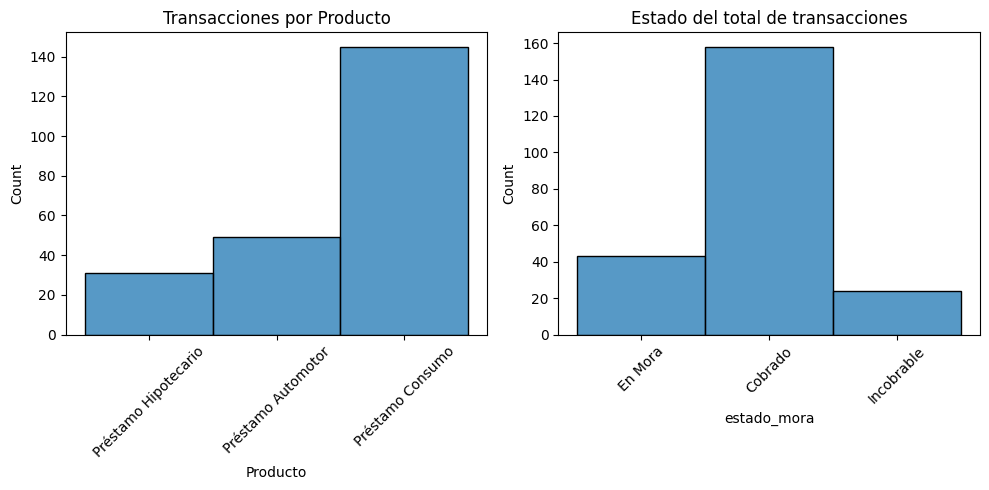

In [14]:
# Hacemos esto porque van a ser varios plots
fig, axis = plt.subplots(1, 2, figsize=(10,5))

# Hacemos dos histogramas para ver la distribución de las variables "Producto" y "estado_mora"
sns.histplot(ax=axis[0], data=df, x="Producto")
sns.histplot(ax=axis[1], data=df, x="estado_mora")

titulos = ["Transacciones por Producto", "Estado del total de transacciones"]
for ax, titulo in zip(axis.flatten(), titulos):
    ax.set_title(titulo)
# Rotación de las etiquetas del eje x para que no se superpongan
for ax in axis.flatten():
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

También nos puede interesar conocer dónde se realizaron la mayor parte de las transacciones y conocer qué vendedores realizaron estas ventas. Observamos que la mayor parte de la actividad comercial se realiza en Montevideo y Canelones, y los vendedores que realizaron el mayor número de ventas se encuentran en estos departamentos. 

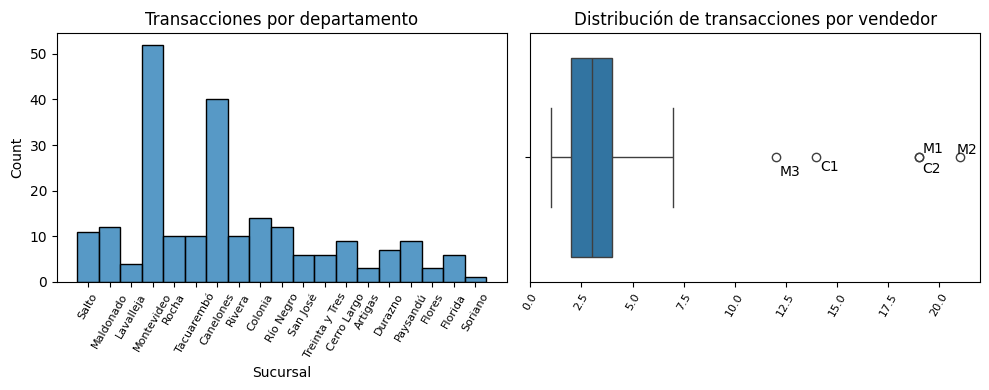

In [15]:
# Usamos adjust_text porque sino se sobrelapan los nombres de los vendedores
from adjustText import adjust_text
log_vendedor = df.groupby("Vendedor").size().sort_values(ascending=False)

fig, axis = plt.subplots(1, 2, figsize=(10,4))
# Histograma de sucursales
sns.histplot(ax=axis[0], data=df, x="Sucursal")
# Boxplot de vendedores con las etiquetas para los top 5
sns.boxplot(ax=axis[1], x=log_vendedor.values)
top5 = log_vendedor.head(5)

titulos = ["Transacciones por departamento", "Distribución de transacciones por vendedor"]
for ax, titulo in zip(axis.flatten(), titulos):
    ax.set_title(titulo)

# Para que los textos no queden sobrepuestos
texts = []
for i, (nombre, valor) in enumerate(top5.items()):
    texts.append(
        axis[1].text(valor, 0.02 * i, nombre)
    )
adjust_text(texts, ax=axis[1])

# Rotamos las etiquetas del eje x
for ax in axis.flatten():
    ax.tick_params(axis='x', rotation=60, labelsize=8)
plt.tight_layout()
plt.show()

## 6. Análisis bivariante
A modo de profundizar en el objetivo planteado agrupamos el monto USD en función a los meses y el tipo de producto al que corresponde en un gráfico de barras apiladas.

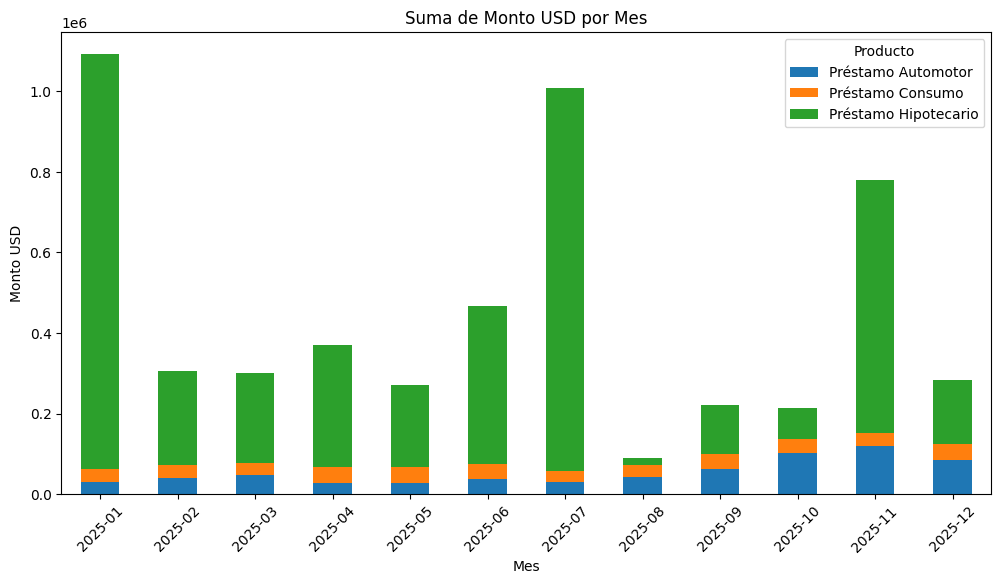

In [16]:
# Agrupamos según el mes y el producto
monthly_sum = (df.groupby(["Mensual", "Producto"])["Monto USD"].sum().unstack())

# Para que queden los meses ordenados
monthly_sum = monthly_sum.sort_index()

# Gráfico de barras para mostrar la suma de dólares transaccionados por mes
# Mostramos el total y la cantidad de dinero asociado a cada producto
monthly_sum.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Suma de Monto USD por Mes")
plt.xticks(rotation=45)
plt.ylabel("Monto USD")
plt.xlabel("Mes")
plt.show()

Este gráfico permite observar la cantidad de dinero que circuló por la empresa a lo largo del año y asociado a qué producto. Esto facilita evaluar los meses de mayor actividad. En base a este gráfico observamos que existe una relacion entre el tipo de producto y el valor asociado al mismo. Es decir, por el análisis univariante vemos que aunque el prestamo hipotecario se pide en menor número, consistentemente es el que mayor dinero requiere. Sin embargo, no podemos hacer un análisis de correlacion entre ambas variables dado que asignarles un número a cada producto no revelaría una distancia real. Sin embargo, en el primero de los siguientes gráficos vemos que esta relación queda clara al enfrentar tipo de producto y su valor por transacción. 

En el próximo gráfico evaluamos el monto por tipo de producto, estado de las transacciones según el monto de las mismas, y podemos obtener métricas sobre los ingresos empíricos de la empresa.

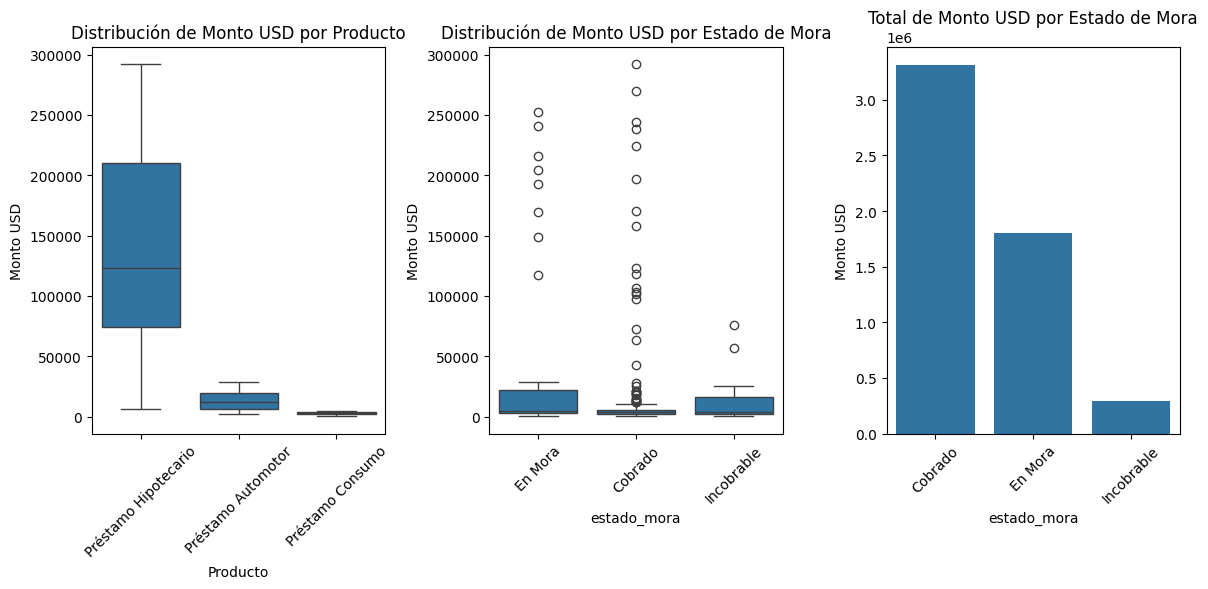

In [17]:
total_metrics = (df.groupby(["estado_mora"])["Monto USD"].sum().reset_index())

df["estado_mora"].value_counts()

fig, axis = plt.subplots(1, 3, figsize=(12,6))
sns.boxplot(ax=axis[0], data=df, x="Producto", y="Monto USD")
sns.boxplot(ax=axis[1], data=df, x="estado_mora", y="Monto USD")
sns.barplot(ax=axis[2], data=total_metrics, x="estado_mora", y="Monto USD")

titulos = ["Distribución de Monto USD por Producto", "Distribución de Monto USD por Estado de Mora", "Total de Monto USD por Estado de Mora"]
for ax, titulo in zip(axis.flatten(), titulos):
    ax.set_title(titulo)

# Rotación de las etiquetas del eje x
for ax in axis.flatten():
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


Por último, buscamos evaluar cómo cambia el tipo de producto y el valor de las transacciones por sucursal. Para ello utilizamos una tabla de contingencia normalizada (para poder comparar entre sucursales) y un boxplot de los valores de las transacciones

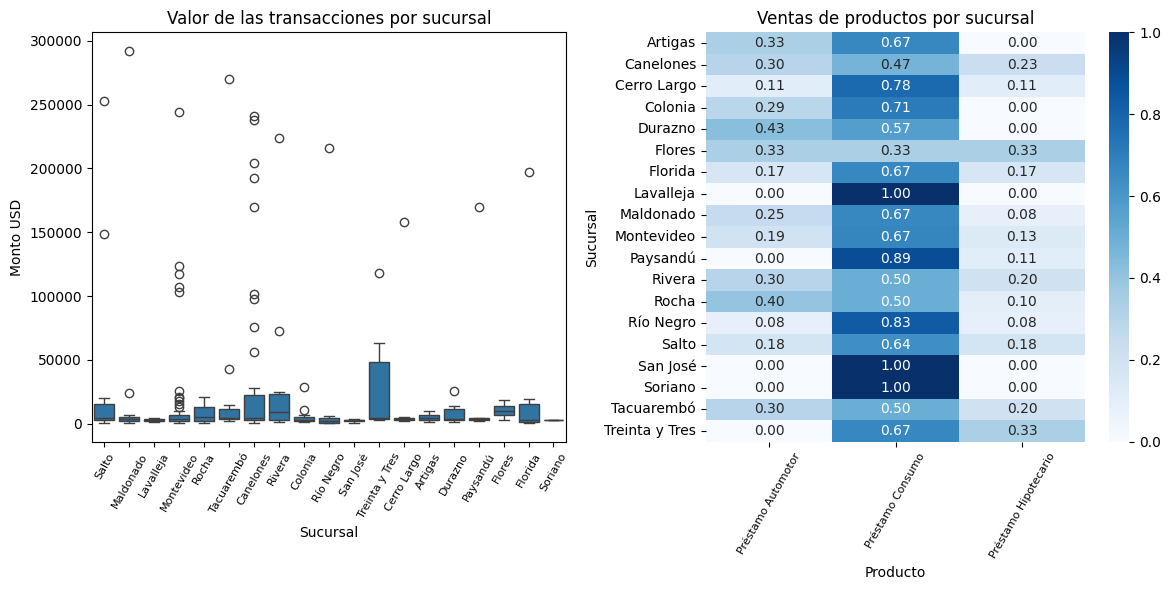

In [18]:
# Normalizamos la tabla de contingencia entre sucursal y producto
tabla_norm = pd.crosstab(df["Sucursal"], df["Producto"], normalize="index")

fig, axis = plt.subplots(1, 2, figsize=(12,6))
# Box plot de sucursal vs monto USD
sns.boxplot(ax=axis[0], data=df, x="Sucursal", y="Monto USD")
# Heatmap de la tabla de contingencia 
sns.heatmap(ax=axis[1], data=tabla_norm, annot=True, fmt=".2f", cmap="Blues")

titulos = ["Valor de las transacciones por sucursal", "Ventas de productos por sucursal"]
for ax, titulo in zip(axis.flatten(), titulos):
    ax.set_title(titulo)

for ax in axis.flatten():
    ax.tick_params(axis='x', rotation=60, labelsize=8)
plt.tight_layout()
plt.show()

### Como resumen de esta sección:
- El préstamo hipotecario es la transacción menos frecuente pero la que requiere la mayor inversión por parte de la empresa. 
- La mayor parte de las transacciones ya han sido cobradas, mientras que casi un quinto de las mismas se encuentran en mora y una parte reducida son incobrables.
- Aún así, la suma de transacciones en mora e incobrables representan más de la mitad del capital recuperado. 
- Montevideo y Canelones son los departamentos donde más productos se comercializaron, siendo el top 5 de vendedores destacados oriundos de estos departamentos.
- Maldonado es la sucursal donde se tramitó el prestamo de mayor valor


## 6. Ingeniería de características
Como siguiente paso realizaremos un análisis para evaluar los outliers presentes en nuestros datos. Esto, sin embargo, veremos no es posible en nuestro set de datos.

In [19]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Fecha,225,2025-07-12 05:00:48,2025-01-01 00:00:00,2025-04-10 00:00:00,2025-07-15 00:00:00,2025-10-20 00:00:00,2025-12-30 00:00:00,NaN
Monto USD,225.0,24022.515556,569.0,2431.0,3832.0,10290.0,292075.0,56066.736896
Fecha Registro en la App,123,2025-07-18 16:35:07.317073,2025-01-04 00:00:00,2025-04-10 00:00:00,2025-07-21 00:00:00,2025-11-02 12:00:00,2026-01-03 00:00:00,NaN


Anteriormente declaramos que:
- Las fechas ocurren en su totalidad en 2025, por lo que no hay ningun "outlier" que afecte los datos de este año
- Las fechas de registro que tienen valor NaN no serán eliminadas ya que  se relacionan a la columna Estado App. 
- Cuando vemos el boxplot "Distribución de transacciones por vendedor" vemos que 5 de ellos se considerarían outliers, pero esto se debe a que la mayoría de las transacciones se da en estos departamentos. No es un dato anómalo.
- Si bien en el gráfico "Valor de las transacciones por sucursal" parecen haber muchos outliers (ej: el mayor valor de la tabla, correspondiendo a Maldonado, es muy distinto que el resto de los valores para esta sucursal), no es correcto eliminarlo ya que se encuentra dentro del percentil 75 de la gráfica "Distribución de Monto USD por Producto". Es decir, si bien es un valor que parece anómalo para el departamento, no es un valor anómalo para el tipo de prestamo en cuestión.

Este último punto podría ser debatido en base al siguiente gráfico, donde mostramos un boxplot con la totalidad de los valores para el monto USD. Sin embargo, ¿es coherente pensar que se manejarian los mismos valores en un prestamo personal que para la compra de una vivenda? Más aún, considerando que este dato NO se encontraría normalizado. Por este motivo, resulta más acertado conservar los "outliers".

Text(0.5, 1.0, 'Distribución de Monto USD')

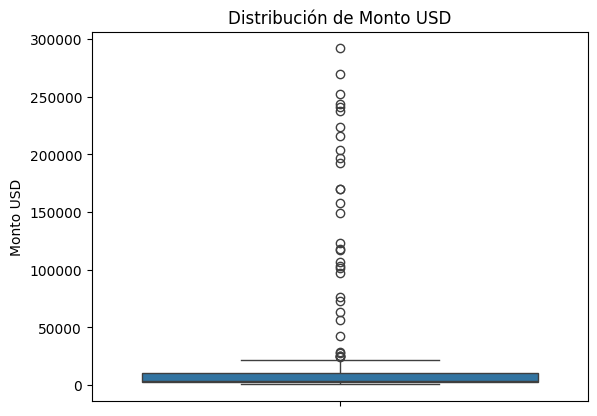

In [20]:
sns.boxplot(data=df,  y="Monto USD")
plt.title("Distribución de Monto USD")

## 7. Split
Para el split, vamos a enfocarnos en intentar predecir el estado en el cual se encontrará el producto en base al resto de las variables. Es decir, dependiendo del monto, el mes, etc intentaremos determinar si este prestamo será cobrado, quedará en mora o será incobrable. Esto le podría servir a una empresa al momento de decidir hacer un préstamo. 

In [21]:
from sklearn import model_selection

In [22]:
df.shape

(225, 9)

Realizaremos algunas modificaciones en las variables que facilitarán la predicción. Por un lado, cambiaremos Estado App a un tipo de dato binario, donde 0 es que no está registrado y 1 que si. También agregamos la columna Dias Hasta Registro, que nos da la cantidad de días desde que el usuario realizó el préstamo hasta que se registró en la App. Si no se registró nunca, se le pone -1.

In [23]:
# Cambiamos los nombres de las variables de estado app
df["Estado App"] = df["Estado App"].map({"No Registrado": 0, "Registrado": 1})

# Para ver si la gente que tarda más en registrarse tiene más probabilidades de ser moroso
df['dias_hasta_registro'] = (
    df['Fecha Registro en la App'] - df['Fecha']
).dt.days

# Si no se registró queda con -1
df['dias_hasta_registro'] = df['dias_hasta_registro'].fillna(-1)


Pusimos diferentes cotas en los montos del préstamo, donde el primer tercil lo consideramos bajo, el segundo medio y el tercero alto. Esto podría ajustarse para mejorar el modelo de ser necesario usando cuartiles, quintiles u otro tipo de rangos.

In [24]:
# Vamos a determinar rangos de prestamo bajo, medio y alto dependiendo de los terciles de monto USD
terciles = df["Monto USD"].quantile([1/3, 2/3])

def monto_div(montos):
    if montos < terciles.loc[1/3]:
        return "Bajo"
    elif montos > terciles.loc[2/3]:
        return "Alto"
    else:
        return "Medio"
    
df["Rango_monto"] = df["Monto USD"].apply(monto_div)
df.head()


,Fecha,Sucursal,Producto,Monto USD,Vendedor,Estado App,Fecha Registro en la App,estado_mora,Mensual,dias_hasta_registro,Rango_monto
168,2025-01-01,Salto,Préstamo Hipotecario,252570.0,S1,1,2025-01-04,En Mora,2025-01,3.0,Alto
223,2025-01-01,Maldonado,Préstamo Automotor,5104.0,A3,1,2025-01-07,Cobrado,2025-01,6.0,Alto
504,2025-05-01,Lavalleja,Préstamo Consumo,2329.0,V2,1,2025-05-07,Cobrado,2025-05,6.0,Bajo
47,2025-07-01,Montevideo,Préstamo Consumo,3761.0,M2,0,NaT,Incobrable,2025-07,-1.0,Medio
300,2025-07-01,Maldonado,Préstamo Automotor,6623.0,A1,1,2025-07-04,En Mora,2025-07,3.0,Alto


Ahora realizaremos el encoding. Para esto dividimos las variables en numéricas, ordinales, nominales y binarias. La diferencia entre ordinales y nominales es que en un caso son cualitativas con órden y en el otro sin un orden. 

Usaremos Ordinal encoder para Rango_monto y One Hot Encoder para las nominales. El one hot encoding nos creará una columna por cada "opción" que hay en la columna original. Por ejemplo, tendremos una columna para sucursal_Montevideo, sucursal_Canelones, sucursal_Flores, etc. donde se indicará mediante 0 o 1 si corresponden para esa observación. Tras aplicar el encoding notaremos que tenemos muchas más columnas que originalmente.

Las binarias y numéricas van por un pass.

In [25]:
numeric_cols = ["dias_hasta_registro"]
ordinal_cols = ["Rango_monto"]
nominal_cols = ["Sucursal", "Producto", "Vendedor"]
yesno_cols   = ["Estado App"]

#Para las ordinales
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

# Encoder para las variables ordinales
ordinal_encoder = OrdinalEncoder(categories=[
    ["Bajo", "Medio", "Alto"]         # Rango de monto
])

#One hot enconder
onehot_encoder = OneHotEncoder(drop="first", handle_unknown="ignore")

#Seteamos esto para aplicarlo a nuestro dataset
preprocessor = ColumnTransformer(
    transformers=[
        ("ord", ordinal_encoder, ordinal_cols), #ordinales
        ("nom", onehot_encoder, nominal_cols),  #nominales
        ("num", "passthrough", numeric_cols),   #numericas
        ("bin", "passthrough", yesno_cols)      #binarios
    ]
)

df.head()

,Fecha,Sucursal,Producto,Monto USD,Vendedor,Estado App,Fecha Registro en la App,estado_mora,Mensual,dias_hasta_registro,Rango_monto
168,2025-01-01,Salto,Préstamo Hipotecario,252570.0,S1,1,2025-01-04,En Mora,2025-01,3.0,Alto
223,2025-01-01,Maldonado,Préstamo Automotor,5104.0,A3,1,2025-01-07,Cobrado,2025-01,6.0,Alto
504,2025-05-01,Lavalleja,Préstamo Consumo,2329.0,V2,1,2025-05-07,Cobrado,2025-05,6.0,Bajo
47,2025-07-01,Montevideo,Préstamo Consumo,3761.0,M2,0,NaT,Incobrable,2025-07,-1.0,Medio
300,2025-07-01,Maldonado,Préstamo Automotor,6623.0,A1,1,2025-07-04,En Mora,2025-07,3.0,Alto


In [26]:
# Eliminamos la columna estado mora del X y la guardamos en y para usarla como target
X = df.drop(columns=["estado_mora"])  # o tu target
y = df["estado_mora"]

# Aplicamos el preprocesamiento a las características
X_transformed = preprocessor.fit_transform(X)

print(X_transformed.shape)  # 225 x 73

(225, 73)


In [27]:
# Guardamos el dataset transformado en un csv
df.to_csv("../data/processed/transformed_and_clean_data.csv", index=False)

In [28]:
# Dividimos el dataset en entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_transformed,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)
print(f"{X_train.shape[0]} samples for training, {X_test.shape[0]} samples for testing")
X_train

180 samples for training, 45 samples for testing


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 894 stored elements and shape (180, 73)>

In [29]:
# Para obtener los nombres de las características después del preprocesamiento
preprocessor.fit(X)
feature_names = preprocessor.get_feature_names_out()

In [30]:
from sklearn.feature_selection import SelectKBest, f_classif

# Top 10 características más importantes según ANOVA F-value
selection_model = SelectKBest(f_classif, k=10)
selection_model.fit(X_train, y_train)

# Máscara de columnas seleccionadas
ix = selection_model.get_support()

feature_names = preprocessor.get_feature_names_out()
selected_features = feature_names[ix]

print("Features seleccionadas:")
print(selected_features)


Features seleccionadas:
['ord__Rango_monto' 'nom__Sucursal_Canelones' 'nom__Sucursal_Montevideo'
 'nom__Vendedor_C1' 'nom__Vendedor_L3' 'nom__Vendedor_M1'
 'nom__Vendedor_N1' 'nom__Vendedor_N2' 'nom__Vendedor_T3'
 'bin__Estado App']


c:\Users\adana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [0 0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\adana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
# Aplicamos las características
X_train_sel = selection_model.transform(X_train)
X_test_sel  = selection_model.transform(X_test)

In [ ]:
# Usamos como modelo Random Forest, pero se pueden probar otros modelos también
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=18)
model.fit(X_train_sel, y_train)

y_pred = model.predict(X_test_sel)

from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
print(confusion_matrix(y_test, y_pred))

Accuracy: 68.89%
[[31  1  1]
 [ 8  0  0]
 [ 4  0  0]]
